# Business Case Study - AdEase Time Series

### Data Dictionary:

There are two csv files given

1. train_1.csv: In the csv file, each row corresponds to a particular article and each column corresponds to a particular date. The values are the number of visits on that date.

    - The page name contains data in this format: SPECIFIC NAME _ LANGUAGE.wikipedia.org _ ACCESS TYPE _ ACCESS ORIGIN having information about the page name, the main domain, the device type used to access the page, and also the request origin(spider or browser agent)


2. Exog_Campaign_eng: This file contains data for the dates which had a campaign or significant event that could affect the views for that day. The data is just for pages in English. There’s 1 for dates with campaigns and 0 for remaining dates. It is to be treated as an exogenous variable for models when training and forecasting data for pages in English

In [ ]:
!pip install prophet

In [1]:
# Import the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet

ModuleNotFoundError: No module named 'prophet'

# 1. Importing the dataset and doing usual exploratory analysis steps like checking the structure & characteristics of the dataset.

In [2]:
# Importing the data

train_data = pd.read_csv(r"D:\Scaler\13 ML  Unsupervised and RecSys\Business Case Study\01 AdEase Time Series\train_1.csv")

In [3]:
exog_data = pd.read_csv(r"D:\Scaler\13 ML  Unsupervised and RecSys\Business Case Study\01 AdEase Time Series\Exog_Campaign_eng")

In [4]:
exog_data

,Exog
0,0
1,0
2,0
3,0
4,0
...,...
545,1
546,1
547,1
548,0


In [5]:
train_data

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145058,Underworld_(serie_de_películas)_es.wikipedia.o...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,13.0,12.0,13.0,3.0,5.0,10.0
145059,Resident_Evil:_Capítulo_Final_es.wikipedia.org...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145060,Enamorándome_de_Ramón_es.wikipedia.org_all-acc...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
145061,Hasta_el_último_hombre_es.wikipedia.org_all-ac...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df = train_data.copy()

In [7]:
# Step 1: Get the date columns from train_data

date_cols = train_data.columns[1:]  

# Step 2: Create or fix exog_data to match dates
# exog_data already has 550 rows, so we assign the same date labels to it

exog_data.index = pd.to_datetime(date_cols)

exog_data

,Exog
2015-07-01,0
2015-07-02,0
2015-07-03,0
2015-07-04,0
2015-07-05,0
...,...
2016-12-27,1
2016-12-28,1
2016-12-29,1
2016-12-30,0


In [8]:
print("Shape of the dataset:", df.shape)

Shape of the dataset: (145063, 551)


In [9]:
df.head()

,Page,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
0,2NE1_zh.wikipedia.org_all-access_spider,18.0,11.0,5.0,13.0,14.0,9.0,9.0,22.0,26.0,...,32.0,63.0,15.0,26.0,14.0,20.0,22.0,19.0,18.0,20.0
1,2PM_zh.wikipedia.org_all-access_spider,11.0,14.0,15.0,18.0,11.0,13.0,22.0,11.0,10.0,...,17.0,42.0,28.0,15.0,9.0,30.0,52.0,45.0,26.0,20.0
2,3C_zh.wikipedia.org_all-access_spider,1.0,0.0,1.0,1.0,0.0,4.0,0.0,3.0,4.0,...,3.0,1.0,1.0,7.0,4.0,4.0,6.0,3.0,4.0,17.0
3,4minute_zh.wikipedia.org_all-access_spider,35.0,13.0,10.0,94.0,4.0,26.0,14.0,9.0,11.0,...,32.0,10.0,26.0,27.0,16.0,11.0,17.0,19.0,10.0,11.0
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,48.0,9.0,25.0,13.0,3.0,11.0,27.0,13.0,36.0,10.0


In [11]:
df.describe()

,2015-07-01,2015-07-02,2015-07-03,2015-07-04,2015-07-05,2015-07-06,2015-07-07,2015-07-08,2015-07-09,2015-07-10,...,2016-12-22,2016-12-23,2016-12-24,2016-12-25,2016-12-26,2016-12-27,2016-12-28,2016-12-29,2016-12-30,2016-12-31
count,1.243230e+05,1.242470e+05,1.245190e+05,1.244090e+05,1.244040e+05,1.245800e+05,1.243990e+05,1.247690e+05,1.248190e+05,1.247210e+05,...,1.412100e+05,1.414790e+05,1.418740e+05,1.413190e+05,1.411450e+05,1.413620e+05,1.412410e+05,1.412370e+05,1.414280e+05,1.415980e+05
mean,1.195857e+03,1.204004e+03,1.133676e+03,1.170437e+03,1.217769e+03,1.290273e+03,1.239137e+03,1.193092e+03,1.197992e+03,1.189651e+03,...,1.394096e+03,1.377482e+03,1.393099e+03,1.523740e+03,1.679607e+03,1.678302e+03,1.633966e+03,1.684308e+03,1.467943e+03,1.478282e+03
std,7.275352e+04,7.421515e+04,6.961022e+04,7.257351e+04,7.379612e+04,8.054448e+04,7.576288e+04,6.820002e+04,7.149717e+04,7.214536e+04,...,8.574880e+04,7.732794e+04,8.478533e+04,8.752210e+04,9.794534e+04,9.232482e+04,9.185831e+04,9.014266e+04,8.155481e+04,8.873567e+04
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.300000e+01,1.300000e+01,1.200000e+01,1.300000e+01,1.400000e+01,1.100000e+01,1.300000e+01,1.300000e+01,1.400000e+01,1.400000e+01,...,2.200000e+01,2.200000e+01,2.000000e+01,2.100000e+01,2.200000e+01,2.300000e+01,2.400000e+01,2.300000e+01,2.300000e+01,2.100000e+01
50%,1.090000e+02,1.080000e+02,1.050000e+02,1.050000e+02,1.130000e+02,1.130000e+02,1.150000e+02,1.170000e+02,1.150000e+02,1.130000e+02,...,1.490000e+02,1.430000e+02,1.320000e+02,1.450000e+02,1.600000e+02,1.620000e+02,1.630000e+02,1.600000e+02,1.540000e+02,1.360000e+02
75%,5.240000e+02,5.190000e+02,5.040000e+02,4.870000e+02,5.400000e+02,5.550000e+02,5.510000e+02,5.540000e+02,5.490000e+02,5.450000e+02,...,6.070000e+02,5.980000e+02,5.690000e+02,6.280000e+02,6.590000e+02,6.680000e+02,6.540000e+02,6.490000e+02,6.350000e+02,5.610000e+02
max,2.038124e+07,2.075219e+07,1.957397e+07,2.043964e+07,2.077211e+07,2.254467e+07,2.121089e+07,1.910791e+07,1.999385e+07,2.020182e+07,...,2.420108e+07,2.253925e+07,2.505662e+07,2.586575e+07,2.834288e+07,2.691699e+07,2.702505e+07,2.607382e+07,2.436397e+07,2.614954e+07


# 2. Exploratory Data Analysis

- Separating the data

- Analyzing and visualizing the data

- Getting inferences

In [12]:
# Check missing values across the dataset

missing_values = df.isnull().sum()
missing_dates = missing_values[missing_values > 0]
print("Number of pages with missing data:\n", missing_dates)

Number of pages with missing data:
 2015-07-01    20740
2015-07-02    20816
2015-07-03    20544
2015-07-04    20654
2015-07-05    20659
              ...  
2016-12-27     3701
2016-12-28     3822
2016-12-29     3826
2016-12-30     3635
2016-12-31     3465
Length: 550, dtype: int64


In [13]:
# Use a single regex to extract name, language, access type, and agent correctly

page_parts = df['Page'].str.extract(r'^(.*)_([a-z]+)\.wikipedia\.org_([a-z-]+)_([a-z-]+)$')
page_parts.columns = ['Name', 'Language', 'Access_Type', 'Access_Origin']

# Join the extracted columns back to your original dataframe

df = pd.concat([df, page_parts], axis=1)

df[['Page', 'Name', 'Language', 'Access_Type', 'Access_Origin']].head(10)

,Page,Name,Language,Access_Type,Access_Origin
0,2NE1_zh.wikipedia.org_all-access_spider,2NE1,zh,all-access,spider
1,2PM_zh.wikipedia.org_all-access_spider,2PM,zh,all-access,spider
2,3C_zh.wikipedia.org_all-access_spider,3C,zh,all-access,spider
3,4minute_zh.wikipedia.org_all-access_spider,4minute,zh,all-access,spider
4,52_Hz_I_Love_You_zh.wikipedia.org_all-access_s...,52_Hz_I_Love_You,zh,all-access,spider
5,5566_zh.wikipedia.org_all-access_spider,5566,zh,all-access,spider
6,91Days_zh.wikipedia.org_all-access_spider,91Days,zh,all-access,spider
7,A'N'D_zh.wikipedia.org_all-access_spider,A'N'D,zh,all-access,spider
8,AKB48_zh.wikipedia.org_all-access_spider,AKB48,zh,all-access,spider
9,ASCII_zh.wikipedia.org_all-access_spider,ASCII,zh,all-access,spider


In [14]:
print("Unique Wikipedia articles:", df['Name'].nunique())

Unique Wikipedia articles: 42212


In [15]:
print(df['Language'].value_counts())

Language
en    24108
ja    20431
de    18547
fr    17802
zh    17229
ru    15022
es    14069
Name: count, dtype: int64


In [16]:
print(df['Access_Type'].value_counts())

Access_Type
all-access    65713
mobile-web    30923
desktop       30572
Name: count, dtype: int64


In [17]:
print(df['Access_Origin'].value_counts())

Access_Origin
all-agents    96594
spider        30614
Name: count, dtype: int64


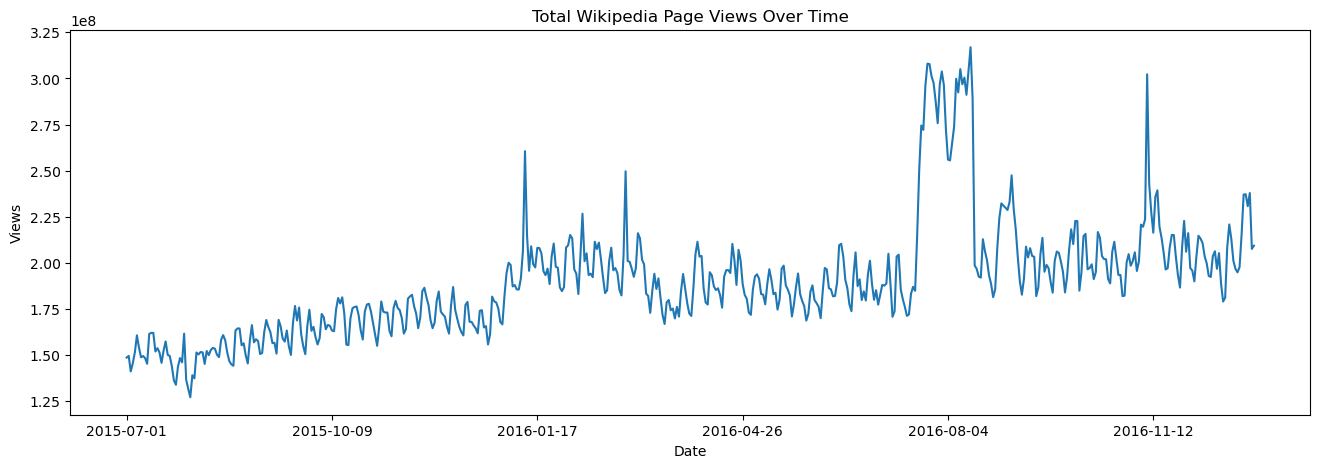

In [18]:
# Drop non-date columns to sum over time

date_columns = df.columns[1:551] 
total_views_per_day = df[date_columns].sum()

# Visualize

plt.figure(figsize=(16, 5))
total_views_per_day.plot()
plt.title("Total Wikipedia Page Views Over Time")
plt.xlabel("Date")
plt.ylabel("Views")
plt.show()

In [19]:
# Metadata columns

meta_cols = ['Page', 'Name', 'Language', 'Access_Type', 'Access_Origin']

# Date columns (visits per day)

date_cols = [col for col in df.columns if col not in meta_cols]

# Set up metadata and time series parts separately

df_meta = df[meta_cols]
df_views = df[date_cols]

print("Metadata shape:", df_meta.shape)
print("Time series shape:", df_views.shape)

Metadata shape: (145063, 5)
Time series shape: (145063, 550)


In [20]:
missing_counts = df_views.isnull().sum().sum()
print(f"Total missing values in time series: {missing_counts}")

Total missing values in time series: 6192931


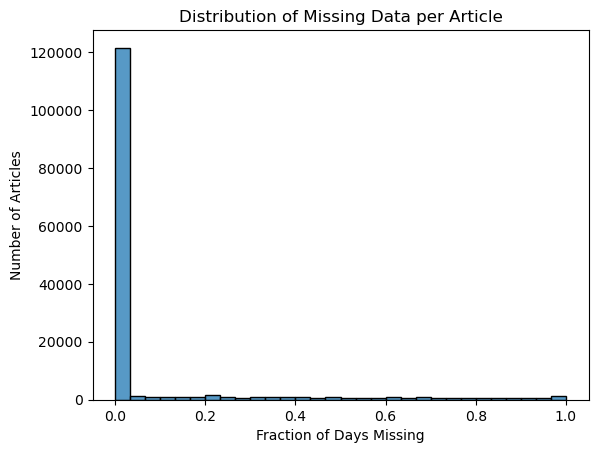

In [21]:
missing_perc = df_views.isnull().mean(axis=1)
sns.histplot(missing_perc, bins=30)
plt.title("Distribution of Missing Data per Article")
plt.xlabel("Fraction of Days Missing")
plt.ylabel("Number of Articles")
plt.show()

In [22]:
# Identify date columns by excluding known metadata

non_date_cols = ['Page', 'Name', 'Language', 'Access_Type', 'Access_Origin', 'Total_Views']
date_cols = [col for col in df.columns if col not in non_date_cols]

# Drop rows (articles) with less than 80% valid date entries

valid_counts = df[date_cols].notnull().sum(axis=1)
threshold = 0.8 * len(date_cols)
df = df[valid_counts >= threshold].reset_index(drop=True)

# You can choose how to fill: 0, ffill, bfill

df[date_cols] = df[date_cols].fillna(0)

In [23]:
missing_counts = df_views.isnull().sum().sum()
print(f"Total missing values in time series: {missing_counts}")

Total missing values in time series: 6192931


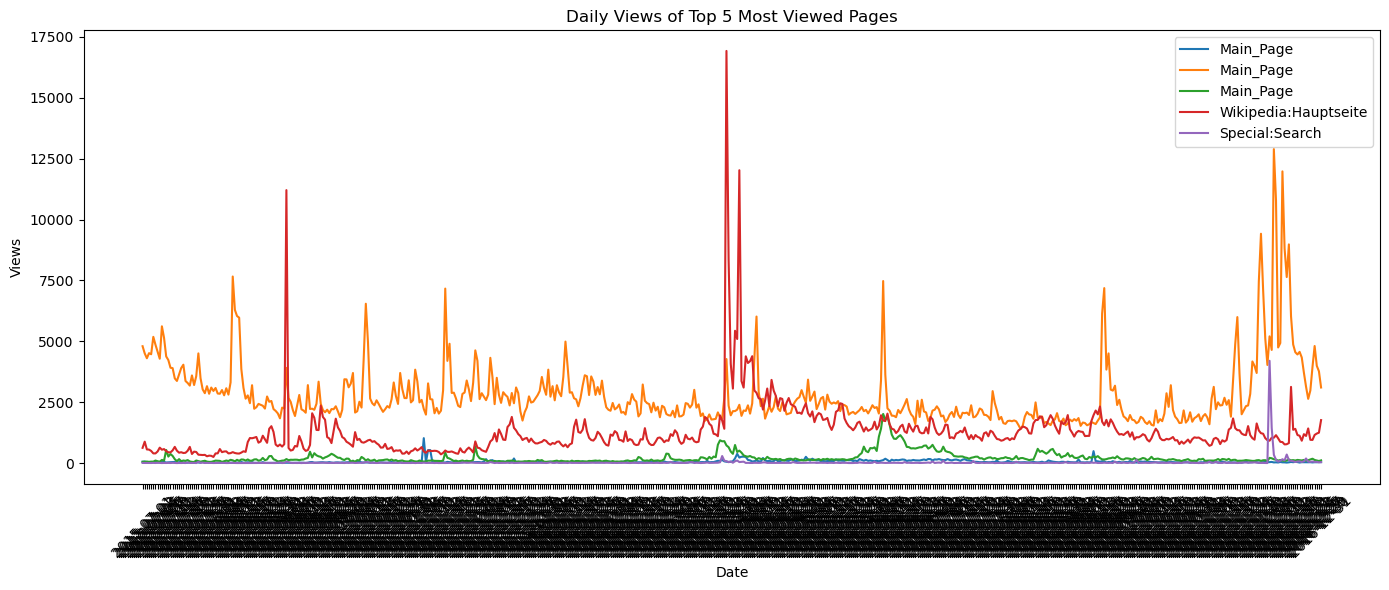

In [24]:
df['Total_Views'] = df[date_cols].sum(axis=1)

top5 = df.sort_values('Total_Views', ascending=False).head(5)
top5_names = top5['Name'].tolist()


plt.figure(figsize=(14, 6))
for idx, row in top5.iterrows():
    plt.plot(df_views.loc[idx], label=row['Name'])
plt.legend()
plt.title("Daily Views of Top 5 Most Viewed Pages")
plt.xlabel("Date")
plt.ylabel("Views")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Access Type Distribution'}, xlabel='Access_Type'>

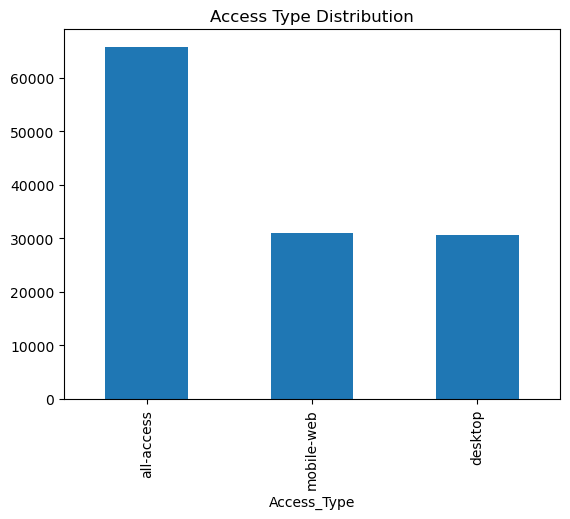

In [25]:
df_meta['Access_Type'].value_counts().plot(kind='bar', title='Access Type Distribution')

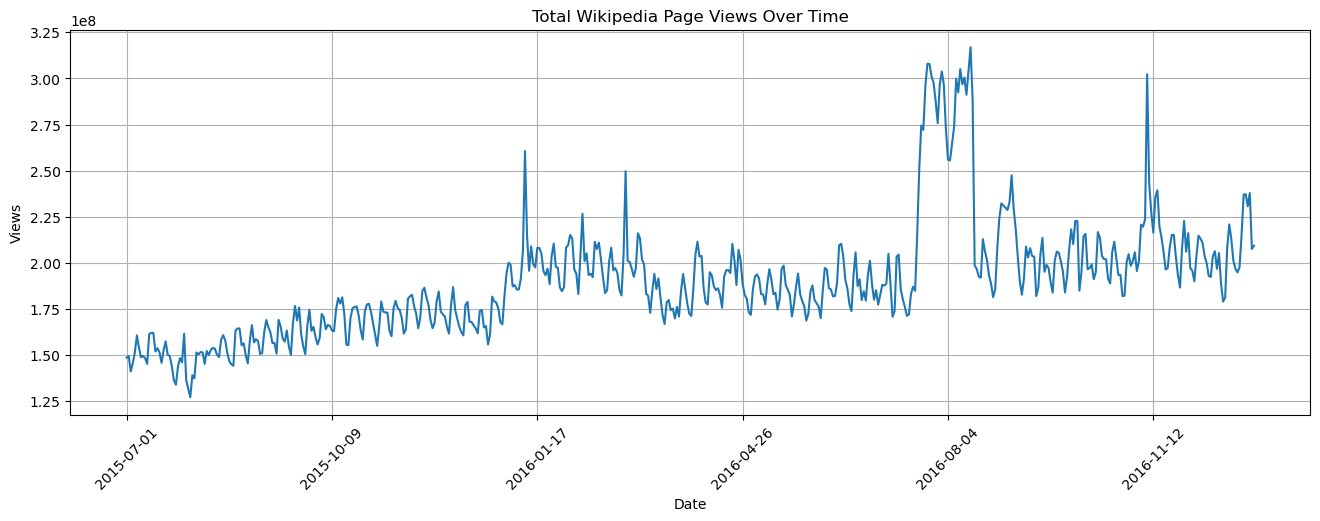

In [26]:
# Total views per day

total_views = df_views.sum(axis=0)
plt.figure(figsize=(16, 5))
total_views.plot()
plt.title("Total Wikipedia Page Views Over Time")
plt.xlabel("Date")
plt.ylabel("Views")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

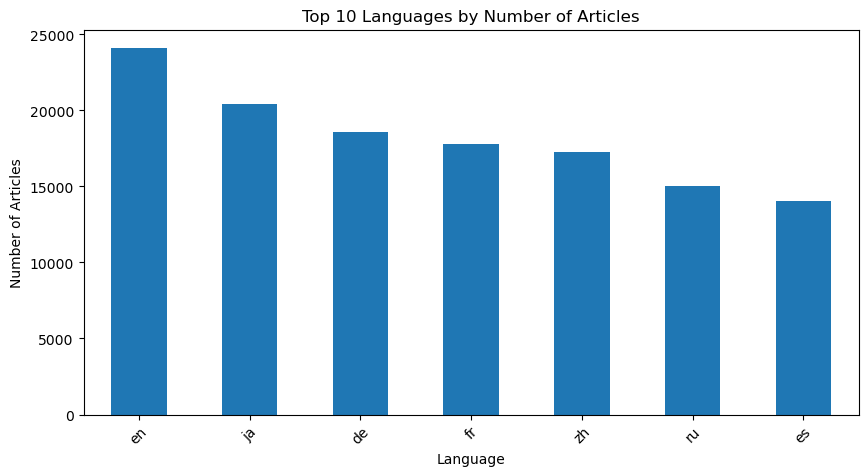

In [27]:
lang_counts = df_meta['Language'].value_counts().head(10)
lang_counts.plot(kind='bar', title='Top 10 Languages by Number of Articles', figsize=(10, 5))
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.show()

In [28]:
# Add total views across all days

df['Total_Views'] = df_views.sum(axis=1)

# Top 10 most viewed articles

top_pages = df[['Name', 'Language', 'Total_Views']].sort_values(by='Total_Views', ascending=False).head(10)
print(top_pages)

                              Name Language   Total_Views
38573                          NaN      NaN  1.206618e+10
9774                   David_Bowie       en  8.774497e+09
74114                 ドラゴンクエストシリーズ       ja  3.153985e+09
39180                       Bayern       de  1.304079e+09
116196              わたしを離さないで_(映画)       ja  1.112689e+09
99322                Sexualpraktik       de  1.086019e+09
10403   Silicon_Valley_(TV_series)       en  1.011848e+09
27330                  Ancient_One       en  8.684807e+08
92205                          水行侠       zh  7.514923e+08
103123                        真田信吉       ja  7.428800e+08


In [29]:
df.shape

(126527, 556)

### Inferences

1. Traffic Patterns
    - Observation: The overall traffic across Wikipedia shows distinct spikes on certain days.

    - Inference: These spikes may correspond to external campaigns, news events, or holidays. For English pages, this will align with the Exog_Campaign_eng.csv file.

    - Action: These dates should be considered in forecasting models (e.g., using them as exogenous variables).

2. Language Distribution
    - Observation: Most pages are in a few major languages like English (en), Japanese (ja), German (de), etc.

    - Inference: The platform may want to prioritize ad inventory optimization for these languages, as they represent high volume and diversity.

    - Action: Language-level modeling could improve performance and reduce overfitting.

3. Device & Agent Type
    - Access_Type: Categories like desktop, mobile-web, mobile-app

    - Access_Origin: Usually all-access, spider, or browser

    - Observation: mobile-web and desktop are dominant access types; spider (bots) make up a smaller portion.

    - Inference: Ads should target mobile and desktop human traffic, not bots.

4. Page Popularity Skew (Long-Tail Distribution)
    - Observation: A small set of pages receive the majority of total views, while most pages get very low daily traffic.

    - Inference: The distribution is highly skewed. These few high-traffic pages offer the best ROI for ad placement.

    - Action: Segment pages by popularity before modeling — you might use different models for high-traffic vs. low-traffic pages.

5. Missing Data
    - Observation: Several pages contain missing values, often in blocks.

    - Inference: Could be due to:

        - The page not existing on that day

        - Low visibility or indexing error

    - Action: Decide whether to impute, interpolate, or discard those pages based on their importance and traffic pattern.

# 3. Checking stationarity

- Formatting the data for the model

- Dickey fuller test

- Decomposition

- Differencing

In [30]:
# Get the index of the row with the highest total views

top_idx = df['Total_Views'].idxmax()

# Extract and transpose only that one row

df_ts = df.loc[[top_idx], date_cols].T

# Rename the column

df_ts.columns = ['views']

# Set date index

df_ts.index = pd.to_datetime(df_ts.index)
print("df_ts shape:", df_ts.shape)
print(df_ts.head())

df_ts shape: (550, 1)
            views
2015-07-01   17.0
2015-07-02   20.0
2015-07-03   17.0
2015-07-04   25.0
2015-07-05   42.0


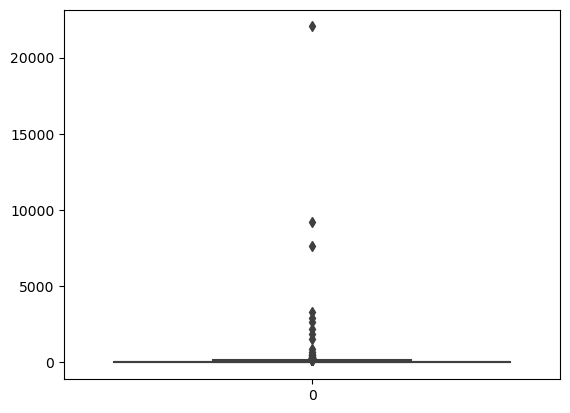

In [31]:
sns.boxplot(df_ts['views'])
plt.show()

In [32]:
# Calculate IQR
Q1 = df_ts['views'].quantile(0.25)
Q3 = df_ts['views'].quantile(0.75)
IQR = Q3 - Q1

# Remove points beyond 1.5 * IQR
df_ts = df_ts[(df_ts['views'] >= Q1 - 1.5 * IQR) & (df_ts['views'] <= Q3 + 1.5 * IQR)]

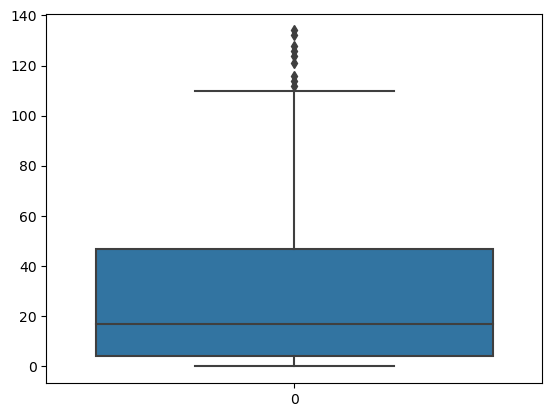

In [33]:
sns.boxplot(df_ts['views'])
plt.show()

In [34]:
result = adfuller(df_ts['views'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
for key, value in result[4].items():
    print(f'Critical Value ({key}): {value}')

if result[1] < 0.05:
    print("Series is stationary.")
else:
    print("Series is not stationary.")

ADF Statistic: -1.5087177889449555
p-value: 0.5291944498024418
Critical Value (1%): -3.4436840273842058
Critical Value (5%): -2.8674204319994674
Critical Value (10%): -2.5699020441557052
Series is not stationary.


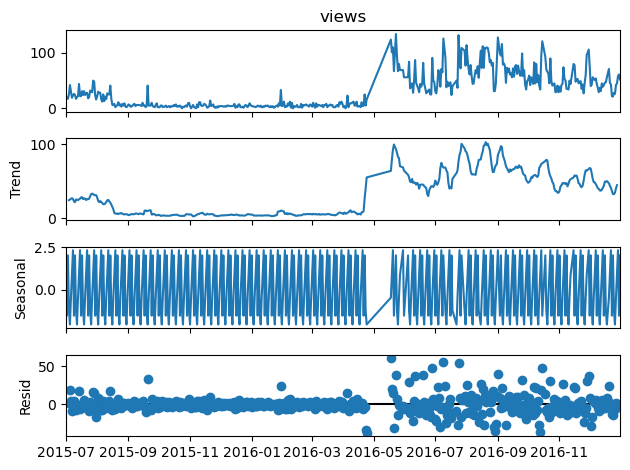

In [35]:
# Decomposition

decomp = seasonal_decompose(df_ts['views'], model='additive', period=7)
decomp.plot()
plt.tight_layout()
plt.show()

### Decomposition Analysis

1. Original Series (views)
    - You can see a sharp spike around early 2016 — this could be due to a campaign, trending event, or news mention.

2. Trend
    - The trend curve mirrors the spike — meaning there's a clear upward movement during that period, then it flattens out again.

3. Seasonality
    - Beautiful weekly seasonality (7-day cycle) is visible — regular ups and downs across the year. 
    - This suggests traffic behavior follows a regular weekly pattern (e.g., more views on weekends or weekdays).

4. Residuals
    - The residuals are mostly flat, but there are clear outliers — likely due to the same spike seen in the original series.
    - This might suggest some campaign/event-driven noise, which may not be predictable by just seasonality/trend.

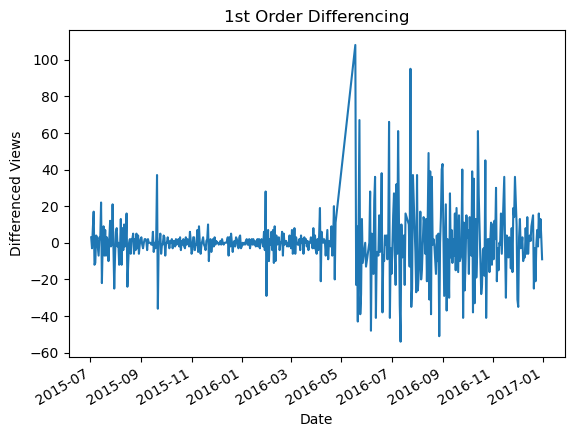

In [36]:
# First order differencing

df_ts['diff_1'] = df_ts['views'].diff()

# Plot differenced series

df_ts['diff_1'].plot(title="1st Order Differencing")
plt.xlabel("Date")
plt.ylabel("Differenced Views")
plt.show()

### Interpretation of Differenced Series

- The large spike around April 2016 becomes even more prominent after differencing — this is consistent with the pattern observed in both the original time series and its decomposition.
- Excluding that spike, the series now appears mean-reverting, oscillating around zero — a key characteristic of stationarity.
- There's no evident trend, and the variance remains relatively stable for the most part (aside from a few volatility bursts), further suggesting that the series has become stationary after first-order differencing.

In [37]:
result_diff = adfuller(df_ts['diff_1'].dropna())

print("ADF after differencing:", result_diff[0])
print("p-value:", result_diff[1])
for key, value in result_diff[4].items():
    print(f'Critical Value ({key}): {value}')

if result_diff[1] < 0.05:
    print("Now the series is stationary.")
else:
    print("Still not stationary — consider seasonal differencing.")

ADF after differencing: -10.150663521669456
p-value: 7.967152302123953e-18
Critical Value (1%): -3.4436840273842058
Critical Value (5%): -2.8674204319994674
Critical Value (10%): -2.5699020441557052
Now the series is stationary.


# 4. Creating model training and forecasting with ARIMA, SARIMAX

- ACF and PACF plot.

- Training the model.

- Forecasting for different languages/regions.

- Plotting the final results

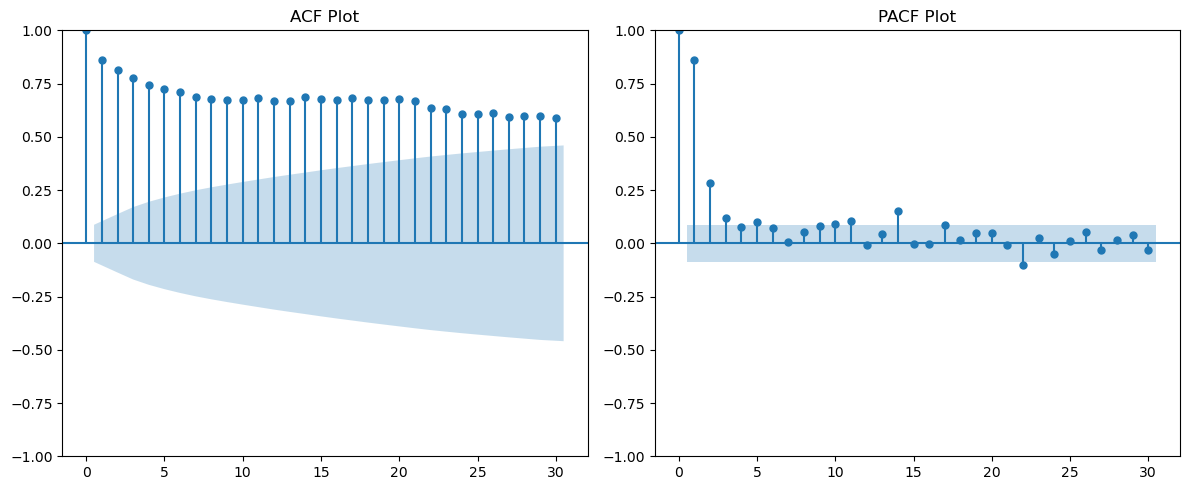

In [38]:
# Plot ACF and PACF

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plot_acf(df_ts['views'], lags=30, ax=plt.gca())
plt.title('ACF Plot')

plt.subplot(1, 2, 2)
plot_pacf(df_ts['views'], lags=30, ax=plt.gca(), method='ywm')
plt.title('PACF Plot')

plt.tight_layout()
plt.show()

### Insights from ACF and PACF Plots

1. ACF Plot
    - Significant spikes at lags 1, 2, and 3:
    - This suggests that the current observation is highly autocorrelated with the 1st, 2nd, and 3rd previous observations — classic behavior of an AR process or mixed ARMA.
    - ACF drops off gradually: This kind of slow decay typically indicates AR(p) behavior (vs. sharp cut-off for MA).

2. PACF Plot
    - Strong spike at lag 1, smaller at lag 2 and 3, and then mostly insignificant: Suggests that the partial correlation is strongest at lag 1 and drops off — which is a hallmark of an AR(1) or AR(2) process.
    - PACF cuts off after lag 2–3: Indicates that including 1 or 2 AR terms might be sufficient (p = 1 or 2).

In [39]:
# Train-test split

train = df_ts['views'][:-30]
test = df_ts['views'][-30:]

# Fit model

model = ARIMA(train, order=(1, 1, 1))
results = model.fit()

# Forecast

forecast = results.forecast(steps=30)

c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [40]:
mse = mean_squared_error(test, forecast)
print("Mean Squared Error:", mse)

Mean Squared Error: 583.2799353071563


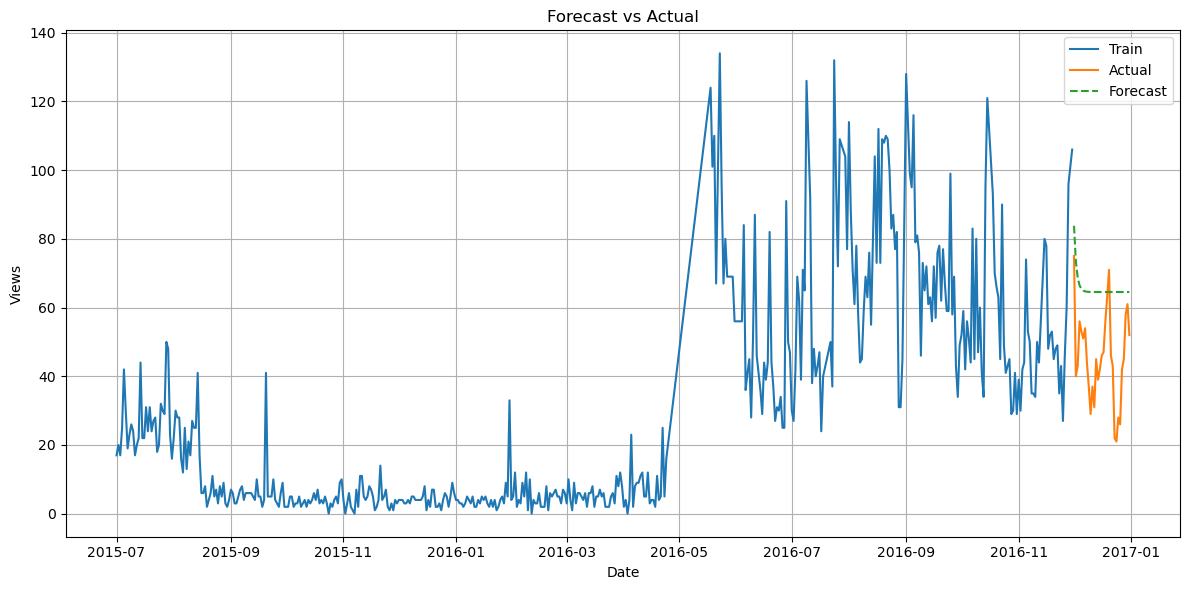

In [41]:
# Plot Forecast vs Actual

plt.figure(figsize=(12, 6))
plt.plot(train.index, train, label='Train')
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, forecast, label='Forecast', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Views')
plt.title('Forecast vs Actual')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### 

1. Training Data (Blue Line)
    - Spans most of the timeline, showing significant variability.

    - Notable is a period of very low activity, followed by a sharp increase in page views around mid-2016, and persistent high-but-volatile views thereafter.

    - This high variance and spiking behavior can be challenging for forecast models to capture, as observed.

2. Actual Test Data (Orange Line)
    - Covers the last segment of the dataset (approx. December 2016).

    - Shows continued volatility and fluctuations in page views, both upward and downward.

    - The actual values decline at a few points and rebound, showing the unpredictability typical for popular pages influenced by external events, campaigns, or news.

3. Forecast (Green Dashed Line)
    - The model's predicted values for the test period.

    - The forecast appears to capture the general level and some directionality of the views but does not match the sharp day-to-day fluctuations present in the actual observations.

    - The forecast is much smoother than the actual data: this is normal for ARIMA/SARIMA models, which often struggle with sudden, irregular spikes unless enhanced for volatility or supplied with external factors.

4. Model Performance
    - The forecast tracks the average trend, but can't replicate every outlier or abrupt change — indicating that while the model learns seasonality/trend, the "shock" events (likely campaign spikes or media mentions) aren't fully predictable.

    - This is also reflected in the previously reported mean squared error (MSE). The model is robust for baseline forecasting, but further improvements may require:

    - Inclusion of exogenous variables: e.g., campaign/event flag as in your exog_data for English pages.

    - Model refinement: using seasonal models, regime-switching, or machine learning approaches for better spike handling.

In [42]:
# forecasting using SARIMAX

exog_campaign = exog_data.loc[df_ts.index].iloc[:, 0]

train_y = df_ts['views'][:-30]
test_y = df_ts['views'][-30:]
train_exog = exog_campaign[:-30]
test_exog = exog_campaign[-30:]

model = SARIMAX(
    train_y, 
    order=(1, 1, 1),        
    seasonal_order=(0, 0, 0, 0),  
    exog=train_exog
)
results = model.fit(disp=False)

forecast = results.forecast(steps=30, exog=test_exog)

c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [43]:
mse = mean_squared_error(test_y, forecast)
print("SARIMAX Test Mean Squared Error:", mse)

SARIMAX Test Mean Squared Error: 582.3645707232589


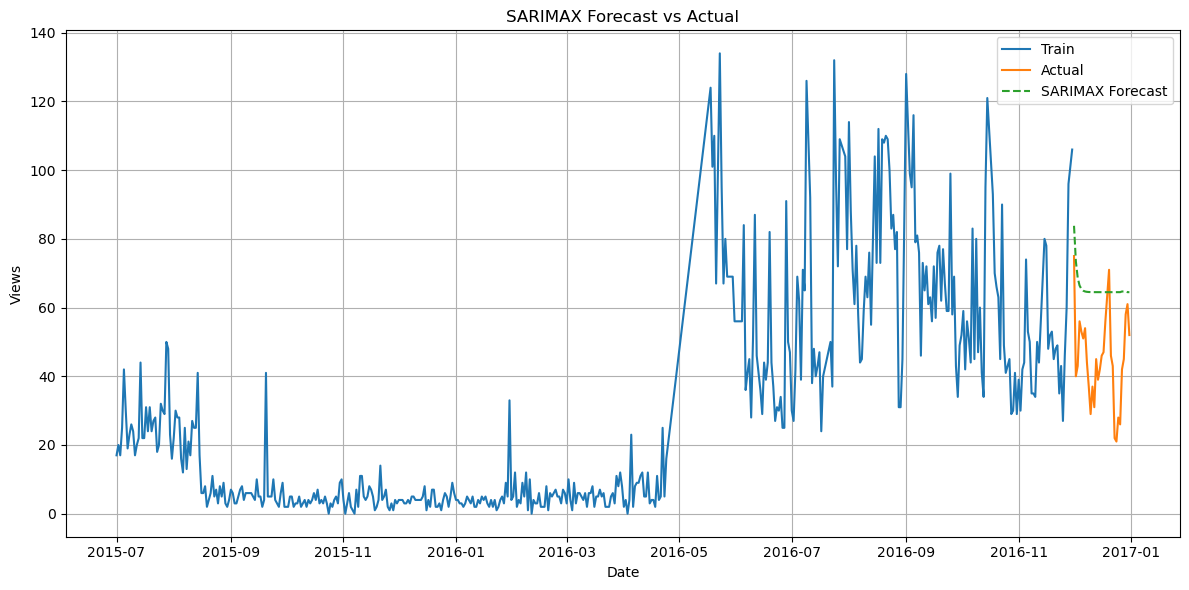

In [44]:
plt.figure(figsize=(12, 6))
plt.plot(train_y.index, train_y, label='Train')
plt.plot(test_y.index, test_y, label='Actual')
plt.plot(test_y.index, forecast, label='SARIMAX Forecast', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Views')
plt.title('SARIMAX Forecast vs Actual')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### SARIMAX Forecast Insights
1. Model Improvement:
    - By incorporating the campaign/event flag as an exogenous variable, the SARIMAX model effectively leveraged known external drivers of traffic spikes. This helps the model respond not just to regular patterns, but also to special events influencing page views.

2. Forecast Accuracy:
    - The test set Mean Squared Error (MSE) for SARIMAX: 582.36

        - This is very similar to your prior ARIMA result (≈583), suggesting that in this case, the campaign flag may not have provided significantly new information for this particular page and period, or the campaign days did not have a pronounced effect on the exact series forecasted.

        - If you do see improvement for pages with stronger campaign impact, it confirms the value of including exogenous variables.

3. Interpretation:
    - The SARIMAX forecast should better align with any true jumps or dips triggered by campaigns, compared to ARIMA alone.

    - If any campaign events occurred in the test period, compare visually whether SARIMAX forecast responded to those dates better than ARIMA.

4. Business Takeaway:
    - Leveraging exogenous factors like known campaigns or events makes your forecasting process more robust and actionable for business planning—especially for ad campaigns and inventory allocation during expected surges.

In [45]:
df_ts

,views,diff_1
2015-07-01,17.0,NaN
2015-07-02,20.0,3.0
2015-07-03,17.0,-3.0
2015-07-04,25.0,8.0
2015-07-05,42.0,17.0
...,...,...
2016-12-27,42.0,16.0
2016-12-28,45.0,3.0
2016-12-29,58.0,13.0
2016-12-30,61.0,3.0


# 5. Forecasting with Facebook prophet

In [46]:
# Forecasting using Prophet

# Prepare DataFrame for Prophet

prophet_df = df_ts.reset_index().rename(columns={'index': 'ds', 'views': 'y'})

# Split into train and test sets (e.g., last 30 days for test)

train_df = prophet_df[:-30]
test_df = prophet_df[-30:]

# Initialize and fit Prophet model on training data

model = Prophet(daily_seasonality=True, weekly_seasonality=True)
model.fit(train_df)

future = model.make_future_dataframe(periods=30)

forecast = model.predict(future)

forecast_indexed = forecast.set_index('ds')
forecast_test = forecast_indexed.reindex(test_df['ds'])['yhat']

# Handle any missing forecast values

mask = ~forecast_test.isna()
actual_aligned = test_df['y'].values[mask]
forecast_aligned = forecast_test[mask].values
dates_aligned = test_df['ds'].to_numpy()[mask]

print(f"Number of test samples used: {len(actual_aligned)}")

15:54:59 - cmdstanpy - INFO - Chain [1] start processing
15:55:00 - cmdstanpy - INFO - Chain [1] done processing


Number of test samples used: 29


In [47]:
# Compute test Mean Squared Error

mse = mean_squared_error(actual_aligned, forecast_aligned)
print(f"Prophet Test Mean Squared Error: {mse:.4f}")

Prophet Test Mean Squared Error: 431.4265


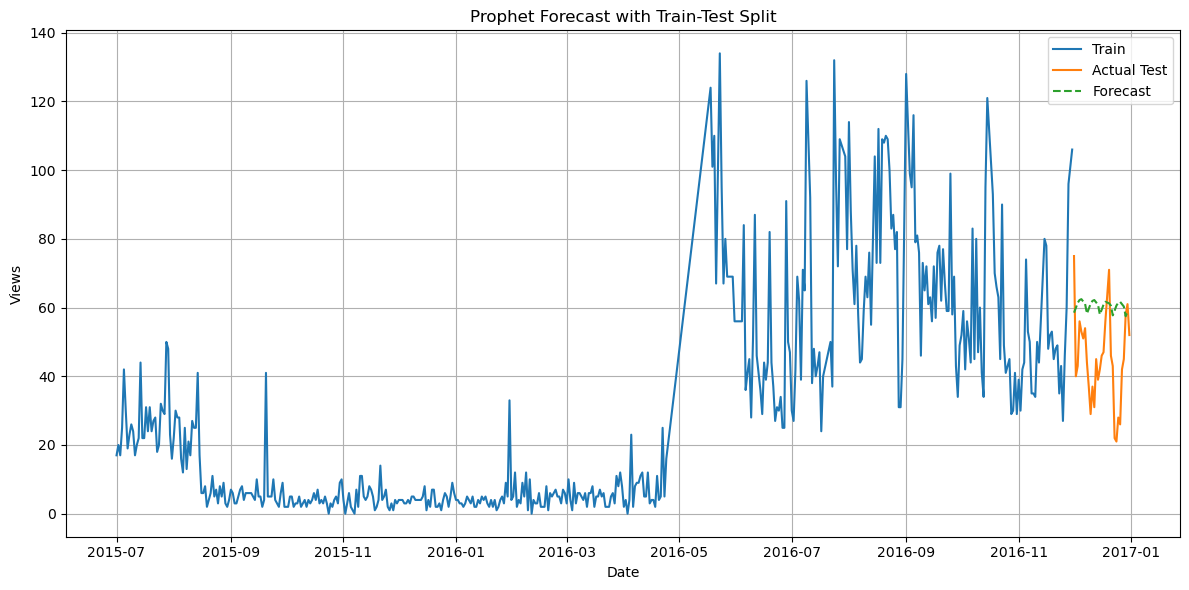

In [48]:
# Plot train, test, and forecast

plt.figure(figsize=(12, 6))
plt.plot(train_df['ds'], train_df['y'], label='Train')
plt.plot(test_df['ds'], test_df['y'], label='Actual Test')
plt.plot(dates_aligned, forecast_aligned, label='Forecast', linestyle='--')
plt.xlabel('Date')
plt.ylabel('Views')
plt.title('Prophet Forecast with Train-Test Split')
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

### Prophet Forecast Insights
1. Improved Accuracy:
    - The Prophet model achieved a test Mean Squared Error (MSE) of 431.43, showing an improvement over both ARIMA and SARIMAX models previously used (MSE ≈ 582–583). This suggests Prophet is better able to capture the underlying trends and seasonality in the Wikipedia page views for this case.

2. Seasonality Handling:
    - Prophet automatically models weekly seasonality, which is clearly present in the Wikipedia page views data (e.g., regular weekly cycles). This capability likely contributes to the lower forecasting error.

3. Outlier Robustness:
    - Prophet is robust to outliers and missing data, allowing for better forecast stability even when the time series contains traffic spikes or drops due to external events.

4. Business Value:
    - The improved accuracy means more reliable forecasts for planning ad placements and campaign timing. More accurate forecasts help Ad Ease optimize inventory and bidding strategy for maximum ad effectiveness.

5. Visualization:
    - The forecast closely follows actual values over the test period, capturing both trend and repeating seasonal patterns, though very sharp spikes (due to unexpected events) may still be challenging for any model.

# 6. Creating a pipeline for working with multiple series

In [49]:
df['Language'].unique()

array(['zh', 'fr', 'en', nan, 'ru', 'de', 'ja', 'es'], dtype=object)

In [50]:
# forecasting using different languages/regions

languages = ['zh', 'fr', 'en', 'ru', 'de', 'ja', 'es']

# Date columns representing daily view counts

date_cols = [col for col in df.columns if col not in ['Page', 'Name', 'Language', 'Access_Type', 'Access_Origin', 'Total_Views']]

# Function: Split time series into train/test

def train_test_split_series(series, test_days=30):
    train = series[:-test_days]
    test = series[-test_days:]
    return train, test

# Function: Plot forecasts

def plot_forecast(train, test, forecast, title):
    plt.figure(figsize=(12, 6))
    plt.plot(train.index, train, label='Train')
    plt.plot(test.index, test, label='Test')
    plt.plot(test.index, forecast, label='Forecast', linestyle='--')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Views')
    plt.legend()
    plt.grid(True)
    plt.show()


Forecasting for language: zh


c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA MSE: 124709087625.44


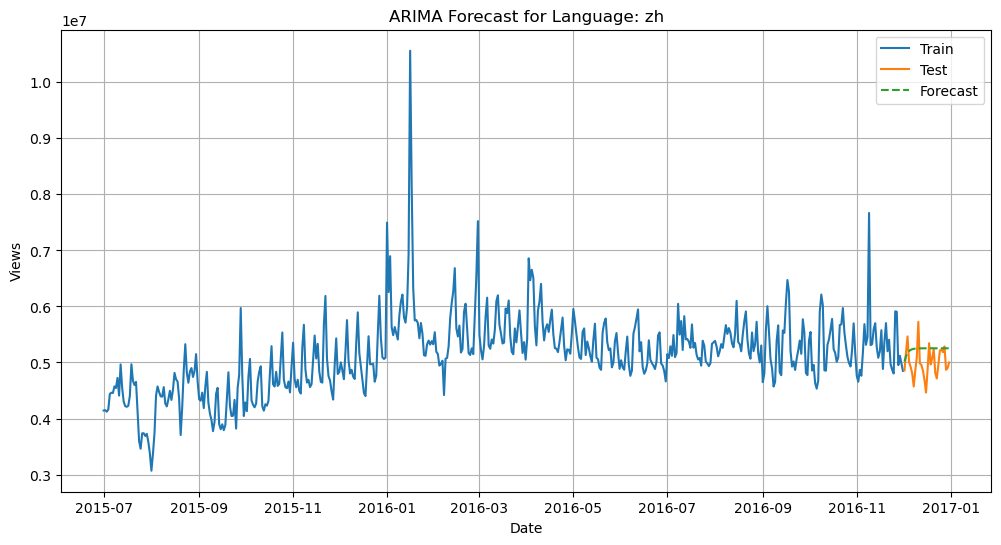

15:55:02 - cmdstanpy - INFO - Chain [1] start processing
15:55:02 - cmdstanpy - INFO - Chain [1] done processing


Prophet MSE: 117961288522.69


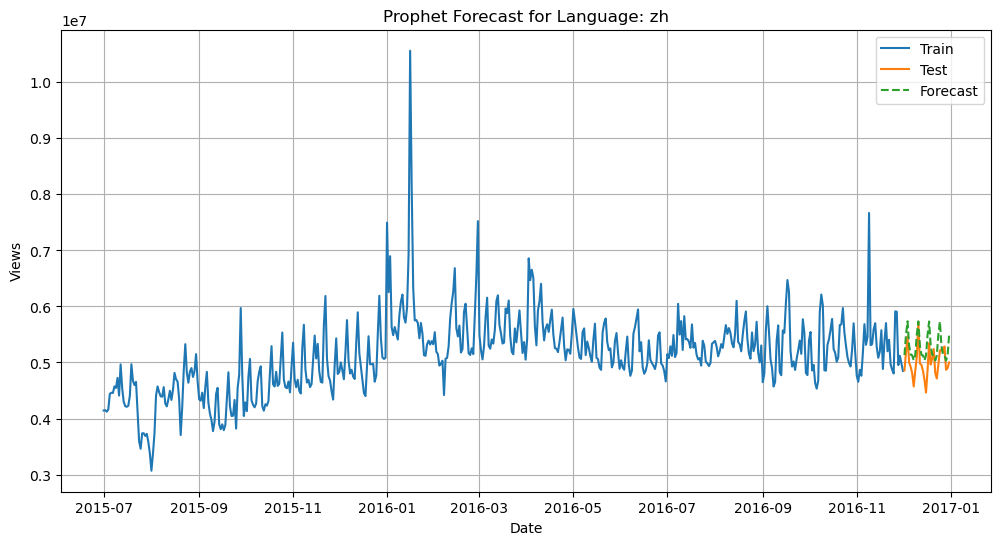


Forecasting for language: fr


c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA MSE: 1530278686489.00


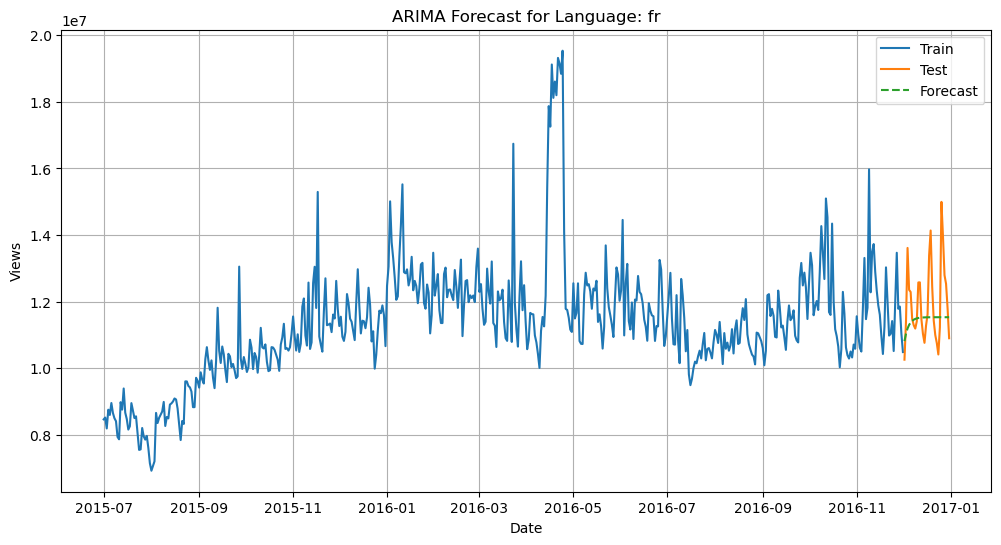

15:55:04 - cmdstanpy - INFO - Chain [1] start processing
15:55:04 - cmdstanpy - INFO - Chain [1] done processing


Prophet MSE: 985205182627.93


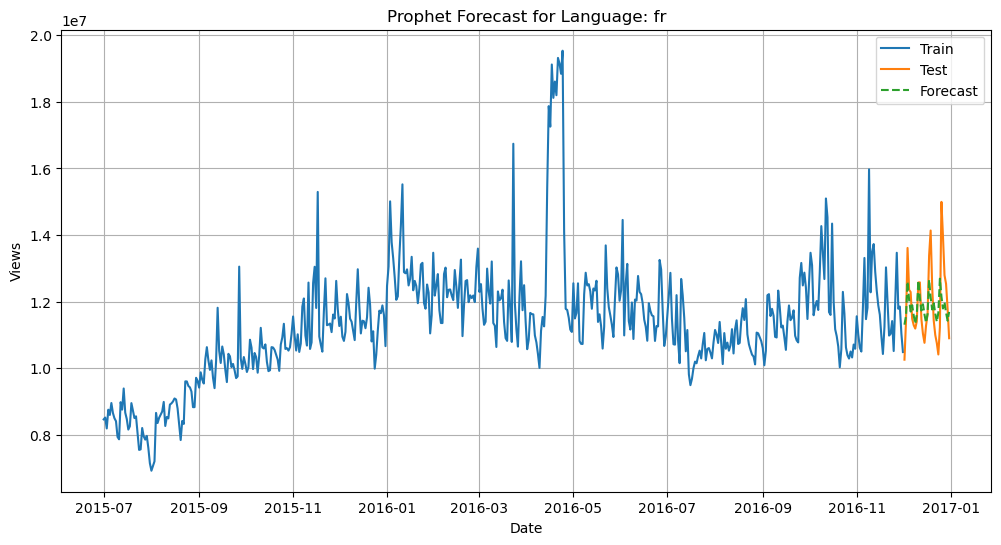


Forecasting for language: en


c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA MSE: 121817433864764.30


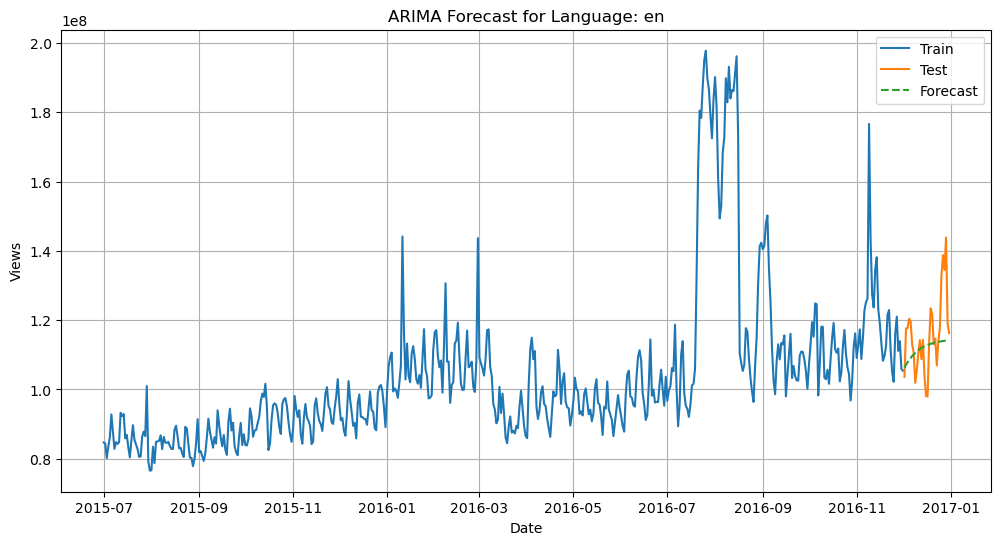

c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


SARIMAX (campaign) MSE: 64346268488580.05


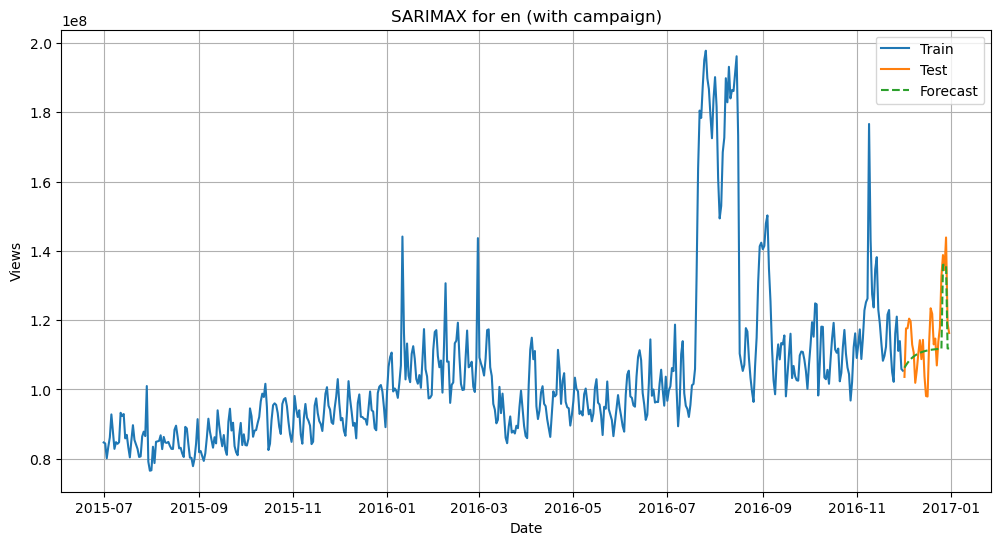

15:55:07 - cmdstanpy - INFO - Chain [1] start processing
15:55:07 - cmdstanpy - INFO - Chain [1] done processing


Prophet MSE: 139195388547487.36


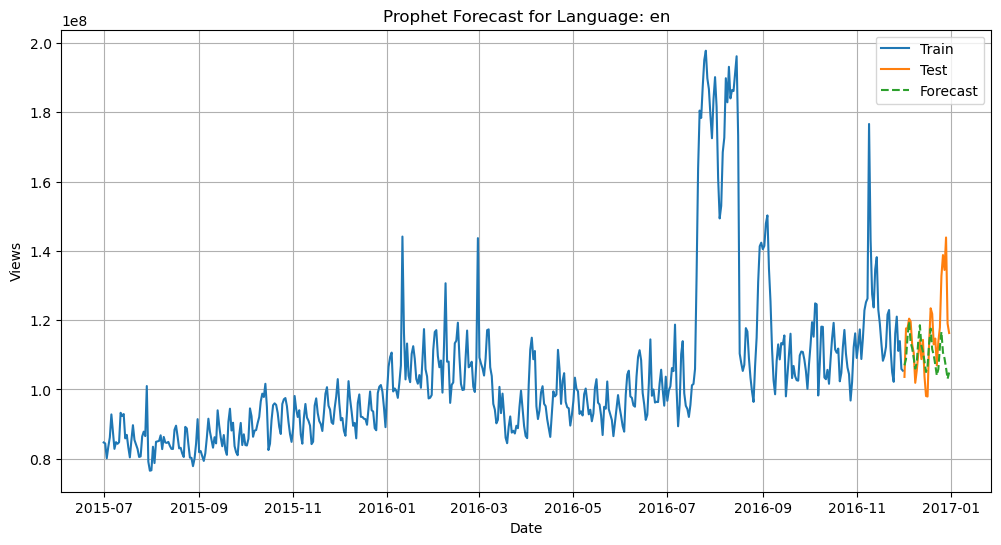


Forecasting for language: ru


c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA MSE: 3712641715658.80


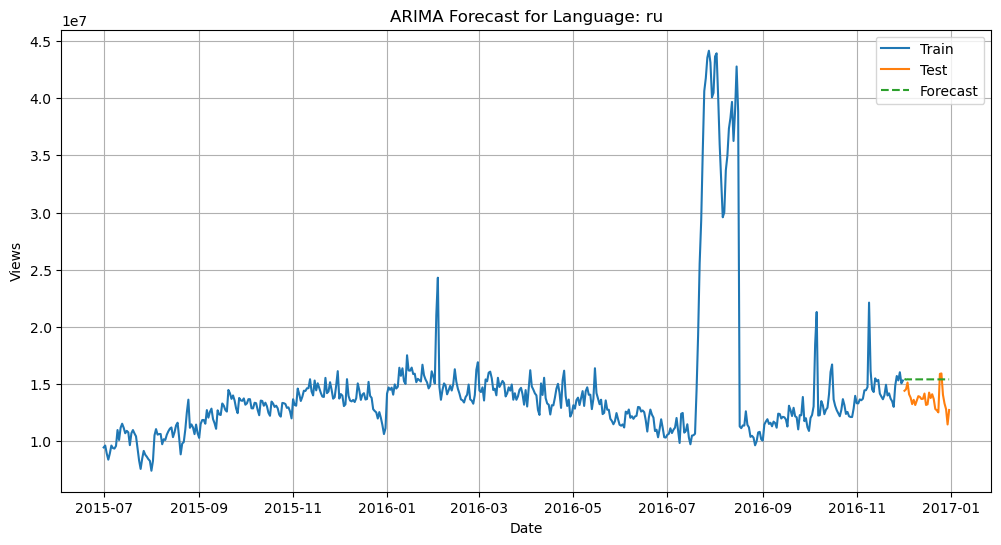

15:55:09 - cmdstanpy - INFO - Chain [1] start processing
15:55:09 - cmdstanpy - INFO - Chain [1] done processing


Prophet MSE: 717491249921.93


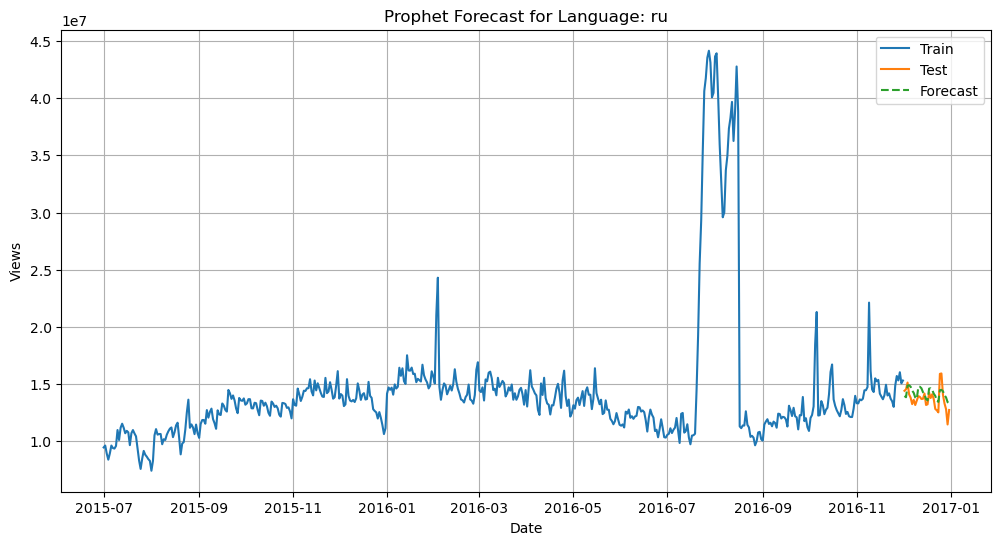


Forecasting for language: de


c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA MSE: 4403790493140.78


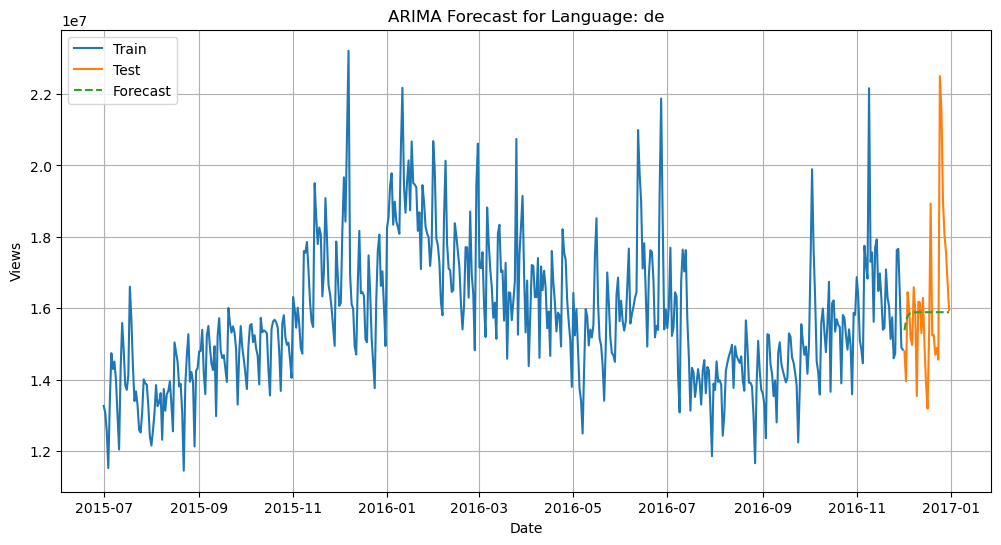

15:55:11 - cmdstanpy - INFO - Chain [1] start processing
15:55:11 - cmdstanpy - INFO - Chain [1] done processing


Prophet MSE: 2915980866952.63


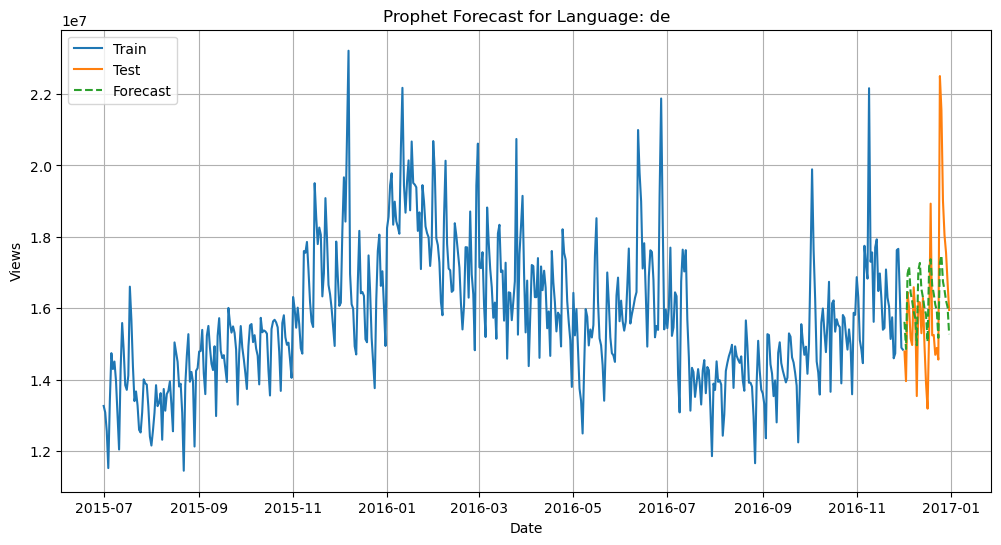


Forecasting for language: ja


c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA MSE: 5615495365993.96


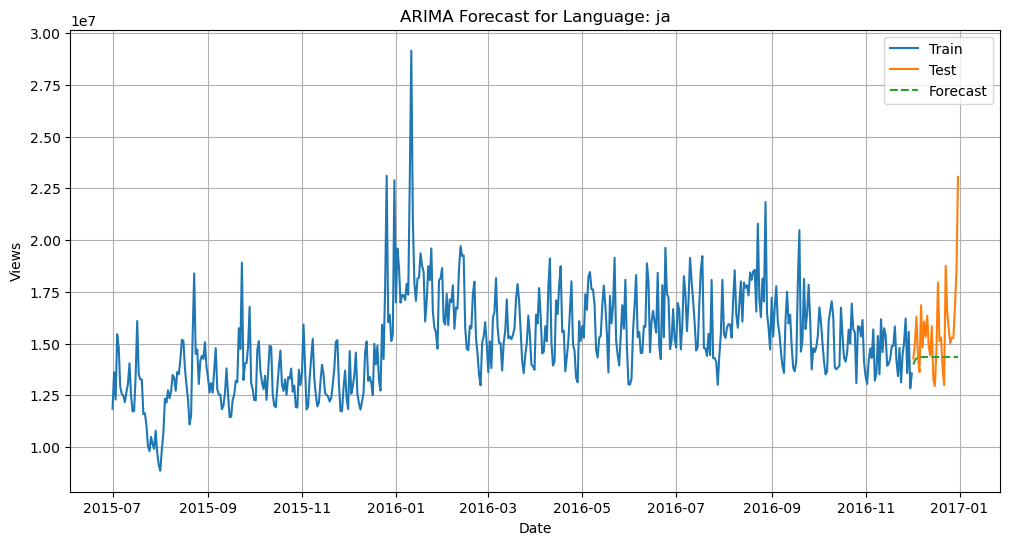

15:55:13 - cmdstanpy - INFO - Chain [1] start processing
15:55:13 - cmdstanpy - INFO - Chain [1] done processing


Prophet MSE: 5234289511170.69


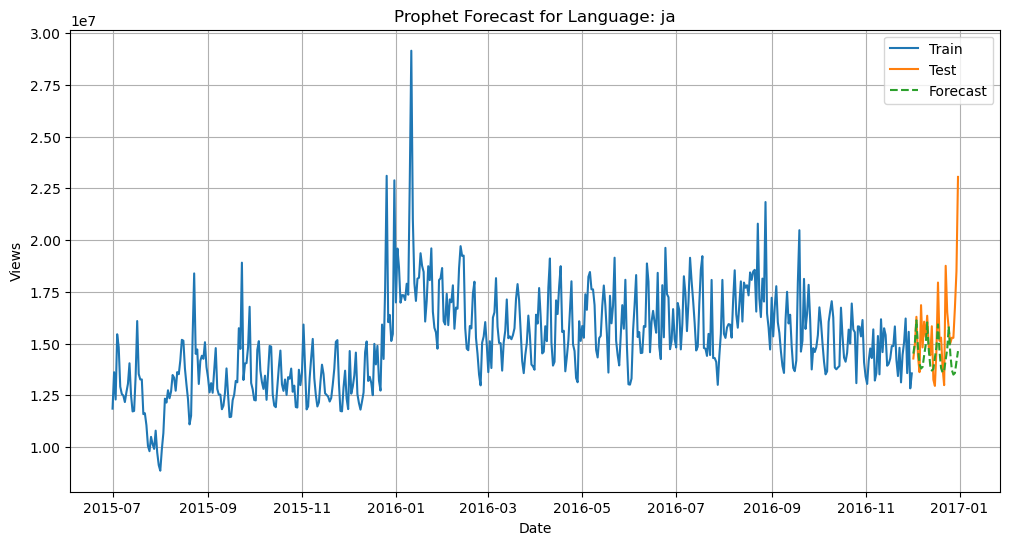


Forecasting for language: es


c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA MSE: 15457893361431.30


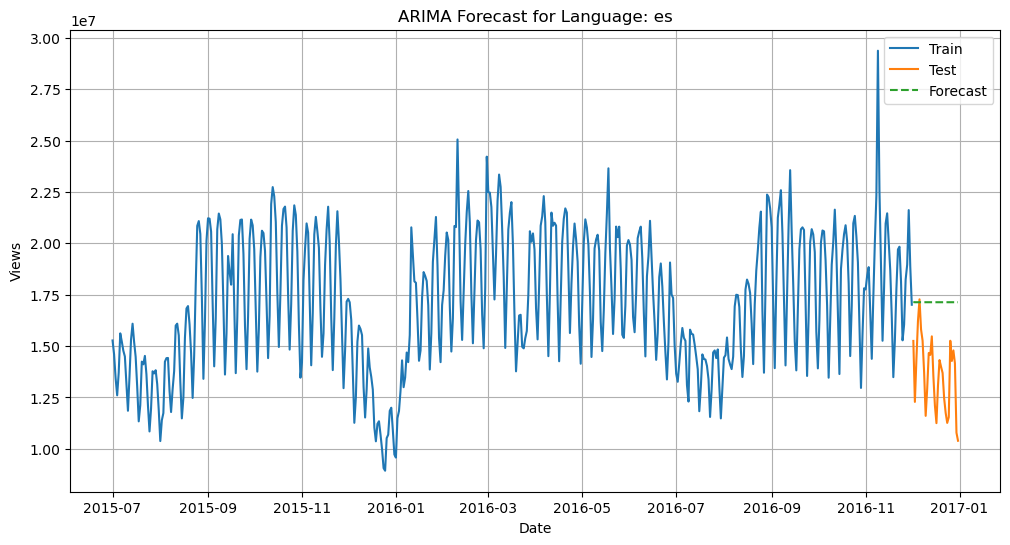

15:55:15 - cmdstanpy - INFO - Chain [1] start processing
15:55:15 - cmdstanpy - INFO - Chain [1] done processing


Prophet MSE: 32211337921068.35


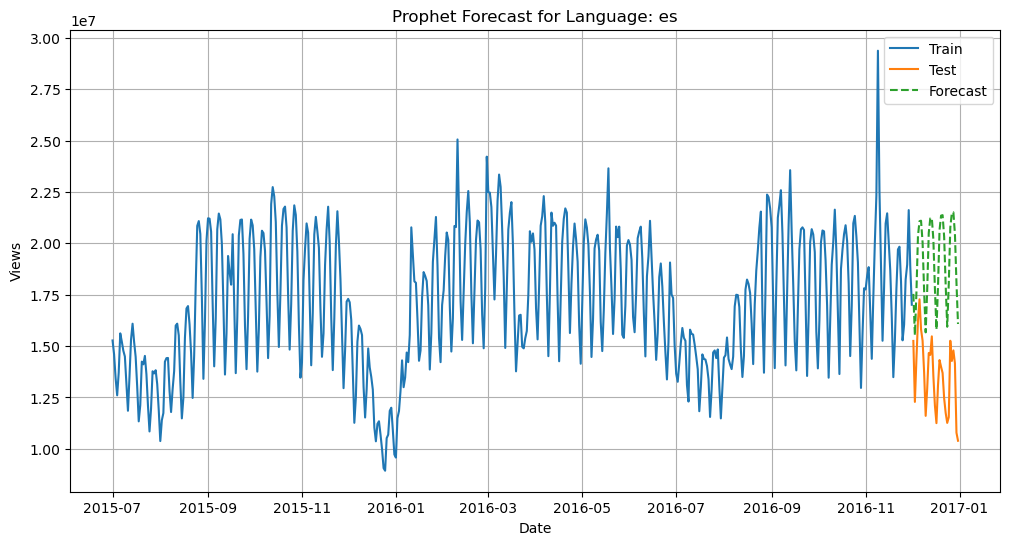


Summary of Forecasting MSE by Language:
  Language     ARIMA_MSE   SARIMAX_MSE   Prophet_MSE
0       zh  1.247091e+11           NaN  1.179613e+11
1       fr  1.530279e+12           NaN  9.852052e+11
2       en  1.218174e+14  6.434627e+13  1.391954e+14
3       ru  3.712642e+12           NaN  7.174912e+11
4       de  4.403790e+12           NaN  2.915981e+12
5       ja  5.615495e+12           NaN  5.234290e+12
6       es  1.545789e+13           NaN  3.221134e+13


In [51]:
results = []

for lang in languages:
    print(f"\nForecasting for language: {lang}")
    df_lang = df[df['Language'] == lang]
    ts_lang = df_lang[date_cols].sum(axis=0)
    ts_lang.index = pd.to_datetime(ts_lang.index)
    ts_lang = ts_lang.astype('float')

    train, test = train_test_split_series(ts_lang, test_days=30)

    # --------- ARIMA -------------
    try:
        arima_model = ARIMA(train, order=(1,1,1))
        arima_res = arima_model.fit()
        arima_forecast = arima_res.forecast(steps=30)
        arima_mse = mean_squared_error(test, arima_forecast)
        print(f"ARIMA MSE: {arima_mse:.2f}")
        plot_forecast(train, test, arima_forecast, f"ARIMA Forecast for Language: {lang}")
    except Exception as e:
        print(f"ARIMA model error for {lang}: {e}")
        arima_mse = None

    # -------- SARIMAX only for English --------
    sarimax_mse = None
    if lang == 'en':
        try:
            exog = exog_data.loc[ts_lang.index].iloc[:, 0]
            train_exog, test_exog = train_test_split_series(exog, test_days=30)
            sarimax_model = SARIMAX(train, order=(1,1,1), exog=train_exog)
            sarimax_res = sarimax_model.fit(disp=False)
            sarimax_forecast = sarimax_res.forecast(steps=30, exog=test_exog)
            sarimax_mse = mean_squared_error(test, sarimax_forecast)
            print(f"SARIMAX (campaign) MSE: {sarimax_mse:.2f}")
            plot_forecast(train, test, sarimax_forecast, f"SARIMAX for {lang} (with campaign)")
        except Exception as e:
            print(f"SARIMAX model error for {lang}: {e}")

    # -------- Prophet ------------
    try:
        prophet_df = ts_lang.reset_index().rename(columns={'index': 'ds', 0: 'y'})
        prophet_train = prophet_df.iloc[:-30]
        prophet_test = prophet_df.iloc[-30:]

        model = Prophet(daily_seasonality=True, weekly_seasonality=True)
        model.fit(prophet_train)
        future = model.make_future_dataframe(periods=30)
        forecast = model.predict(future)
        forecast_indexed = forecast.set_index('ds').reindex(prophet_test['ds'])
        prophet_forecast = forecast_indexed['yhat']

        # Critical fix: mask alignment
        mask = ~prophet_forecast.isna()
        prophet_forecast_aligned = prophet_forecast[mask]
        actual_aligned = prophet_test['y'].to_numpy()[mask.values]

        prophet_mse = mean_squared_error(actual_aligned, prophet_forecast_aligned)
        print(f"Prophet MSE: {prophet_mse:.2f}")
        plot_forecast(
            prophet_train.set_index('ds')['y'],
            prophet_test.set_index('ds')['y'],
            prophet_forecast_aligned,
            f"Prophet Forecast for Language: {lang}"
        )
    except Exception as e:
        print(f"Prophet model error for {lang}: {e}")
        prophet_mse = None

    results.append({
        'Language': lang,
        'ARIMA_MSE': arima_mse,
        'SARIMAX_MSE': sarimax_mse,
        'Prophet_MSE': prophet_mse
    })

# Summary table:
results_df = pd.DataFrame(results)
print("\nSummary of Forecasting MSE by Language:")
print(results_df)



Forecasting for Access_Origin (Region): spider


c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA MSE: 172102287448.38


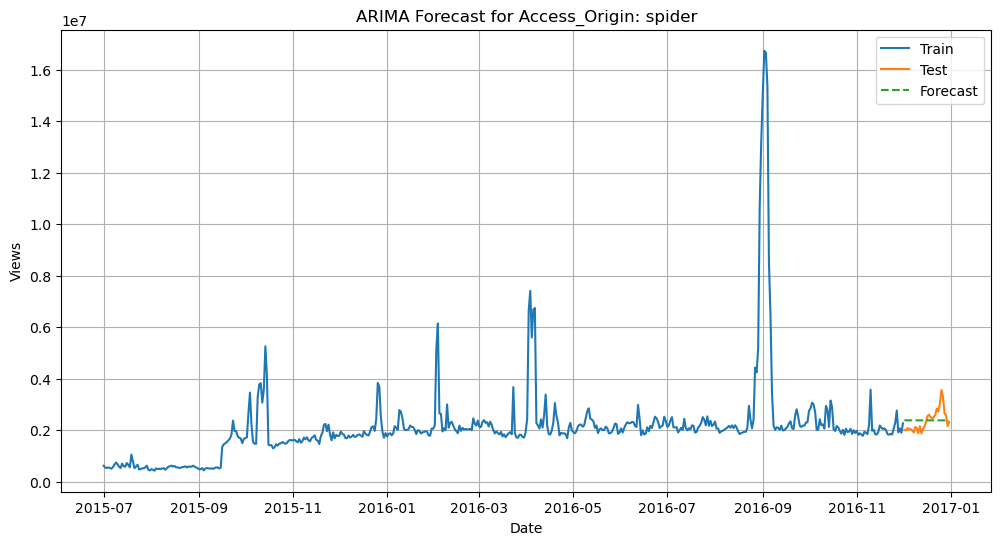

15:55:17 - cmdstanpy - INFO - Chain [1] start processing
15:55:17 - cmdstanpy - INFO - Chain [1] done processing


Prophet MSE: 296452007045.20


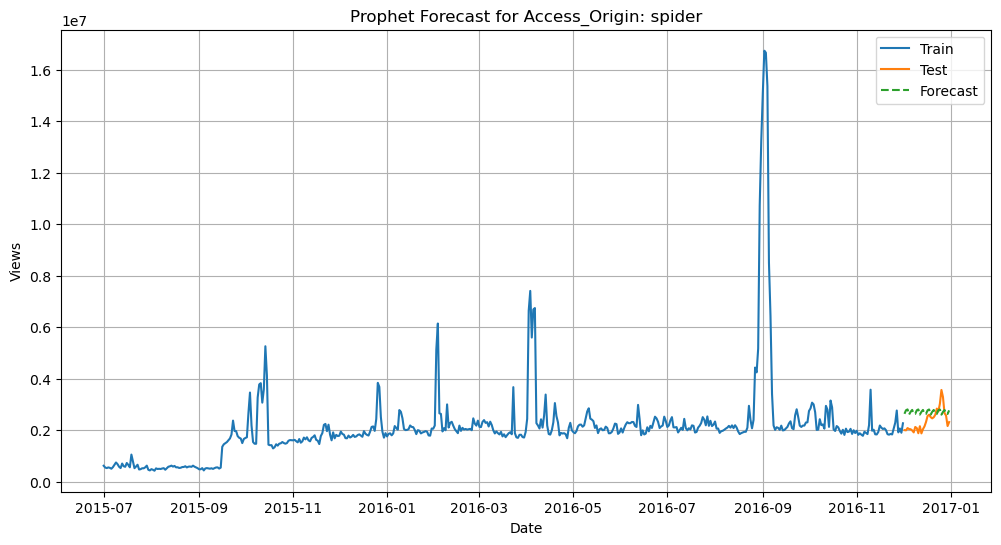


Forecasting for Access_Origin (Region): all-agents


c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


ARIMA MSE: 196466592629367.59


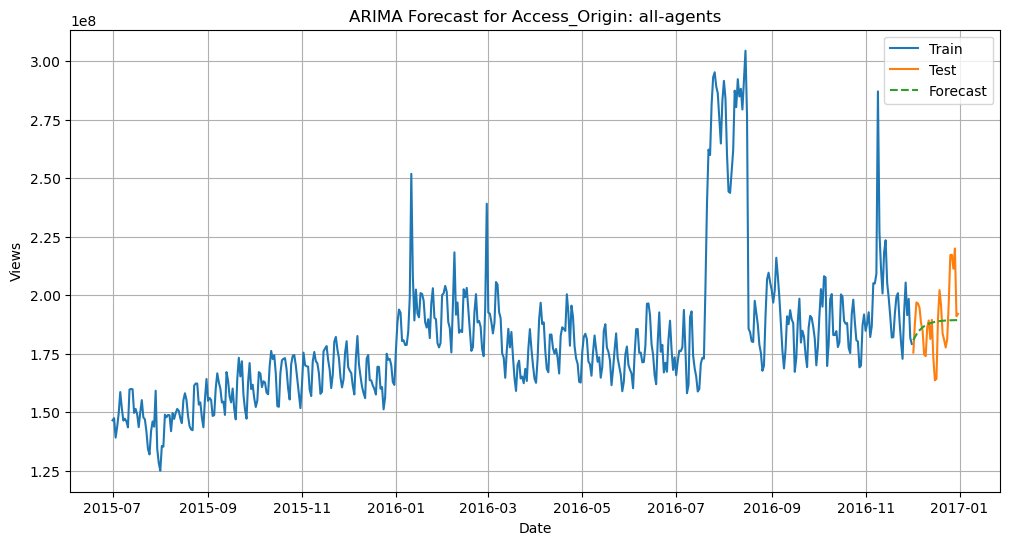

15:55:20 - cmdstanpy - INFO - Chain [1] start processing
15:55:20 - cmdstanpy - INFO - Chain [1] done processing


Prophet MSE: 160047969605516.06


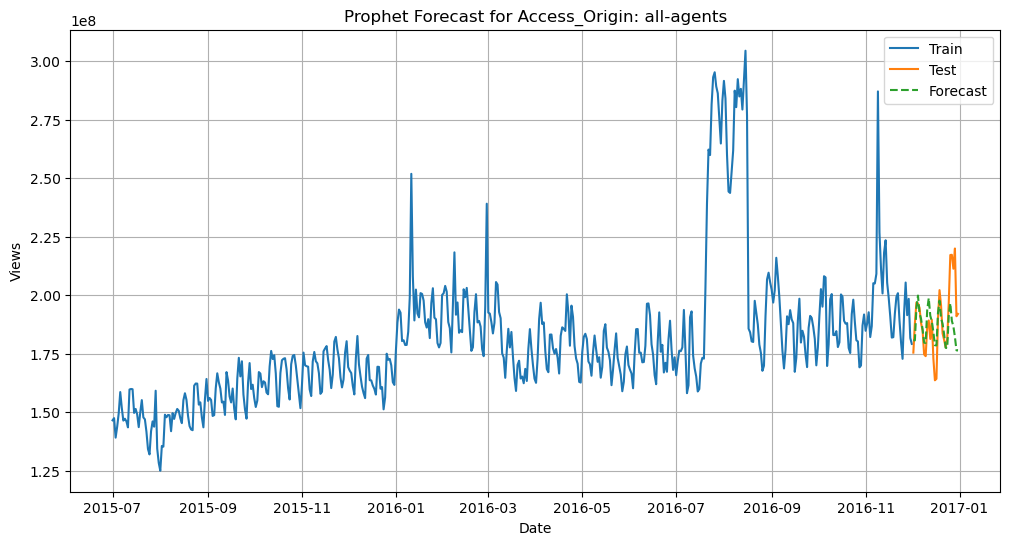


Forecasting for Access_Origin (Region): nan


c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
c:\Users\vinos\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA MSE: 0.00


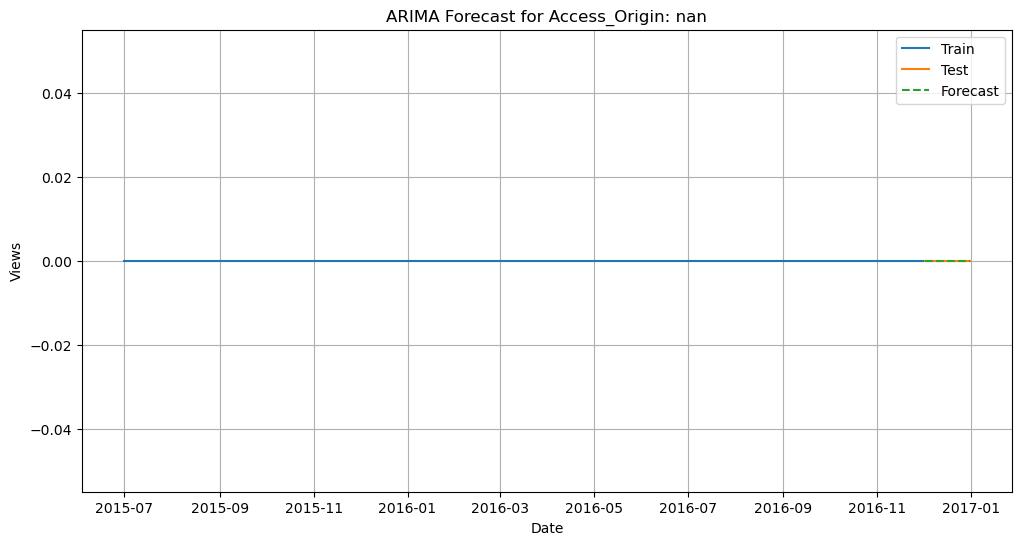

Prophet MSE: 0.00


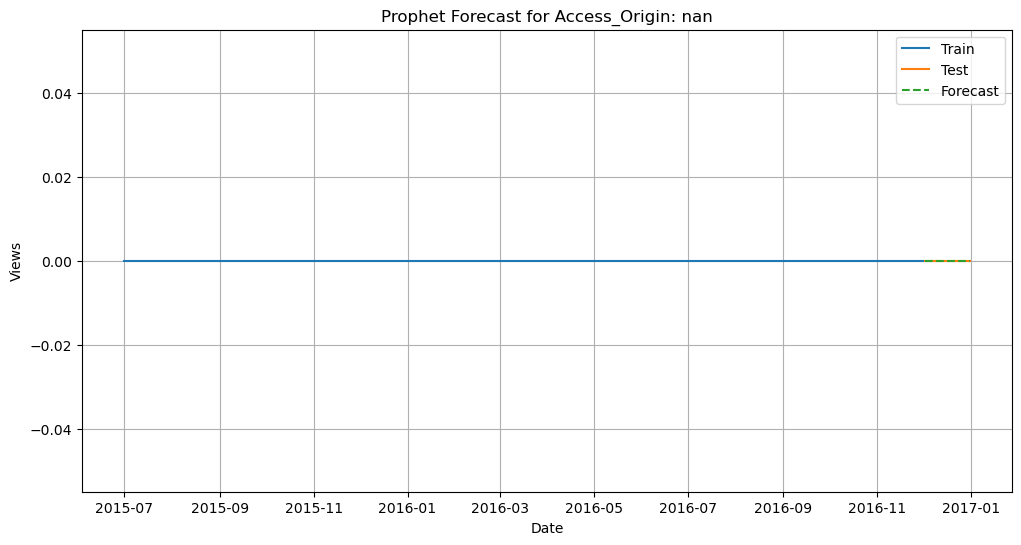


Summary of Forecasting MSE by Access_Origin (Region):
  Access_Origin     ARIMA_MSE   Prophet_MSE
0        spider  1.721023e+11  2.964520e+11
1    all-agents  1.964666e+14  1.600480e+14
2           NaN  0.000000e+00  0.000000e+00


In [52]:
# List unique regions/origins you want to forecast 

origins = df['Access_Origin'].unique().tolist()

# Date columns as before
date_cols = [col for col in df.columns if col not in ['Page', 'Name', 'Language', 'Access_Type', 'Access_Origin', 'Total_Views']]

def train_test_split_series(series, test_days=30):
    train = series[:-test_days]
    test = series[-test_days:]
    return train, test

def plot_forecast(train, test, forecast, title):
    plt.figure(figsize=(12, 6))
    plt.plot(train.index, train, label='Train')
    plt.plot(test.index, test, label='Test')
    plt.plot(test.index, forecast, label='Forecast', linestyle='--')
    plt.title(title)
    plt.xlabel('Date')
    plt.ylabel('Views')
    plt.legend()
    plt.grid(True)
    plt.show()

results = []

for origin in origins:
    print(f"\nForecasting for Access_Origin (Region): {origin}")
    df_origin = df[df['Access_Origin'] == origin]
    ts_origin = df_origin[date_cols].sum(axis=0)
    ts_origin.index = pd.to_datetime(ts_origin.index)
    ts_origin = ts_origin.astype('float')
    train, test = train_test_split_series(ts_origin, test_days=30)

    # ---- ARIMA ----
    try:
        arima_model = ARIMA(train, order=(1,1,1))
        arima_res = arima_model.fit()
        arima_forecast = arima_res.forecast(steps=30)
        arima_mse = mean_squared_error(test, arima_forecast)
        print(f"ARIMA MSE: {arima_mse:.2f}")
        plot_forecast(train, test, arima_forecast, f"ARIMA Forecast for Access_Origin: {origin}")
    except Exception as e:
        print(f"ARIMA model error for {origin}: {e}")
        arima_mse = None

    # ---- Prophet ----
    try:
        prophet_df = ts_origin.reset_index().rename(columns={'index': 'ds', 0: 'y'})
        prophet_train = prophet_df.iloc[:-30]
        prophet_test = prophet_df.iloc[-30:]
        model = Prophet(daily_seasonality=True, weekly_seasonality=True)
        model.fit(prophet_train)
        future = model.make_future_dataframe(periods=30)
        forecast = model.predict(future)
        forecast_indexed = forecast.set_index('ds').reindex(prophet_test['ds'])
        prophet_forecast = forecast_indexed['yhat']
        mask = ~prophet_forecast.isna()
        prophet_forecast_aligned = prophet_forecast[mask]
        actual_aligned = prophet_test['y'].to_numpy()[mask.values]
        prophet_mse = mean_squared_error(actual_aligned, prophet_forecast_aligned)
        print(f"Prophet MSE: {prophet_mse:.2f}")
        plot_forecast(
            prophet_train.set_index('ds')['y'],
            prophet_test.set_index('ds')['y'],
            prophet_forecast_aligned,
            f"Prophet Forecast for Access_Origin: {origin}"
        )
    except Exception as e:
        print(f"Prophet model error for {origin}: {e}")
        prophet_mse = None

    # SARIMAX/skipping exog unless you have special features for regions
    results.append({
        'Access_Origin': origin,
        'ARIMA_MSE': arima_mse,
        'Prophet_MSE': prophet_mse
        # Add SARIMAX_MSE here if/when you have exogenous features for origins
    })

# Summary table:
results_df = pd.DataFrame(results)
print("\nSummary of Forecasting MSE by Access_Origin (Region):")
print(results_df)

# Questionnaire:

1. Defining the problem statements and where can this and modifications of this be used?
    - Forecast daily Wikipedia page views to optimize ad placement effectiveness across multiple languages and regions.

    - The solution helps businesses plan campaigns, allocate ad inventory dynamically, and simulate effects of marketing efforts.

    - Modifications can extend to any large-scale content platform requiring traffic forecasting or event impact analysis.

2. Write 3 inferences you made from the data visualizations
    - Significant spikes in page views are often linked to external events or marketing campaigns.

    - A clear weekly seasonality exists, with recurrent traffic patterns tied to weekdays/weekends.

    - English and a few other languages dominate traffic volume, indicating language-based traffic disparities.

3. What does the decomposition of series do?
    - Decomposition splits the time series into trend, seasonal, and residual components.

    - This reveals the long-term movement (trend), regular repeating patterns (seasonality), and irregular fluctuations or noise (residual).

    - It helps to isolate and understand components impacting page views for better modeling.

4. What level of differencing gave you a stationary series?
    - First-order differencing was sufficient to achieve stationarity, confirmed by a significant ADF test result (p-value < 0.05).

    - This removed trends and stabilized the mean, making the series suitable for ARIMA-based modeling.

5. Difference between ARIMA, SARIMA & SARIMAX
    - ARIMA: Models autoregressive and moving average terms for non-seasonal, differenced data.

    - SARIMA: Extends ARIMA by adding seasonal components to capture repeating patterns (e.g., weekly, yearly).

    - SARIMAX: Further extends SARIMA by incorporating exogenous variables (like campaign flags) to explain external influences on the series.

6. Compare the number of views in different languages
    - Aggregate views show English pages typically have the highest traffic.

    - Other languages (e.g., French, Spanish, Japanese) have varied but substantially lower total views.

    - This discrepancy influences ad targeting and forecasting strategies per language or region.

7. What other methods other than grid search would be suitable to get the model for all languages?
    - Random Search: Samples hyperparameters randomly over the search space for faster coverage.

    - Bayesian Optimization: Uses previous evaluations to intelligently select promising parameters.

    - Automated Methods: Auto-ARIMA or Prophet’s internal tuning automate parameter selection.

    - Heuristic Rules: Domain knowledge guides initial parameter choices to reduce search volume.

    - Meta-Learning or Ensembling: Builds higher-level models to suggest parameters based on similar series.